# Spike / bad-pixel finder — mfx100895324 runs 36 & 37 (PIXEL SPACE)

Purpose: identify the detector **columns** that produce spikes in the Fe Kα / Kβ
spectra so they can be listed under `patch_pixels: pixels: [...]` in
`mfx100895324_static_xes.yaml`.

This notebook is deliberately **raw and un-rotated**:
- reads the existing smalldata HDF5 directly (read-only, no pipeline)
- **no rotation**, **no energy-axis conversion** — everything is in raw
  detector pixel/column indices
- reproduces the same reduction the pipeline uses (ADU threshold → sum xray
  shots → sum signal rows) but **without patching**, so spikes are visible

Detector `epix100_1/ROI_area` is (nshots, 300 rows, 710 cols).
Dispersion = columns; the two emission bands sit at different rows:

| Line | Detector rows (ROI) | Analyzer |
|------|---------------------|----------|
| Fe Kα | 228–248 | LiNbO3 (2 3 -4) |
| Fe Kβ | 158–180 | Ge (6 2 0) |

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter, label

# ---- Configuration (must match the YAML) --------------------------------
SMD_DIR   = '/sdf/data/lcls/ds/mfx/mfx100895324/hdf5/smalldata'
RUNS      = [36, 37]
DET_KEY   = 'epix100_1/ROI_area'
ADU_THRESH = 3.0                 # matches filter_detector_adu in the YAML
KA_ROWS   = (228, 248)           # matches rois[0] (Fe Kalpha)
KB_ROWS   = (158, 180)           # matches rois[1] (Fe Kbeta)
CHUNK     = 4000                 # shots per read chunk (memory control)

smd_files = {rn: f'{SMD_DIR}/mfx100895324_Run{rn:04d}.h5' for rn in RUNS}
for rn, fp in smd_files.items():
    print(f'run {rn}: {fp}  exists={os.path.exists(fp)}')

run 36: /sdf/data/lcls/ds/mfx/mfx100895324/hdf5/smalldata/mfx100895324_Run0036.h5  exists=True
run 37: /sdf/data/lcls/ds/mfx/mfx100895324/hdf5/smalldata/mfx100895324_Run0037.h5  exists=True


## 1. Build summed 2D image + 1D band spectra (raw, unpatched)

Sums all xray-on shots (ADU-thresholded) across both runs into a single
300×710 image, then collapses each emission-band row range to a 710-pixel
spectrum. No rotation, no patching.

In [2]:
sum2d = None
n_xray_total = 0

for rn, fp in smd_files.items():
    with h5py.File(fp, 'r') as f:
        xray = f['lightStatus/xray'][:].astype(bool)
        N = len(xray)
        dset = f[DET_KEY]
        if sum2d is None:
            sum2d = np.zeros(dset.shape[1:], dtype=np.float64)  # (300, 710)
        for start in range(0, N, CHUNK):
            end = min(start + CHUNK, N)
            xmask = xray[start:end]
            if xmask.sum() == 0:
                continue
            raw = dset[start:end][xmask].astype(np.float64)
            raw[raw < ADU_THRESH] = 0.0
            sum2d += raw.sum(axis=0)
            n_xray_total += int(xmask.sum())
            print(f'  run {rn}: shots {start}-{end}   (xray total {n_xray_total})', end='\r')
    print()

# 1D band spectra = sum over the band's rows -> (710,)
ka_spec = sum2d[KA_ROWS[0]:KA_ROWS[1], :].sum(axis=0)
kb_spec = sum2d[KB_ROWS[0]:KB_ROWS[1], :].sum(axis=0)
cols = np.arange(sum2d.shape[1])
print(f'\nSummed {n_xray_total} xray shots. sum2d {sum2d.shape}, '
      f'Kα spec {ka_spec.shape}, Kβ spec {kb_spec.shape}')

  run 36: shots 28000-28842   (xray total 28842)
  run 37: shots 28000-28831   (xray total 57673)

Summed 57673 xray shots. sum2d (300, 710), Kα spec (710,), Kβ spec (710,)


## 2. Summed 2D image with band ROIs marked

Bright vertical streaks / isolated hot points are the spike sources. Note
their **column** index (x-axis) — that is what goes into the patch list.

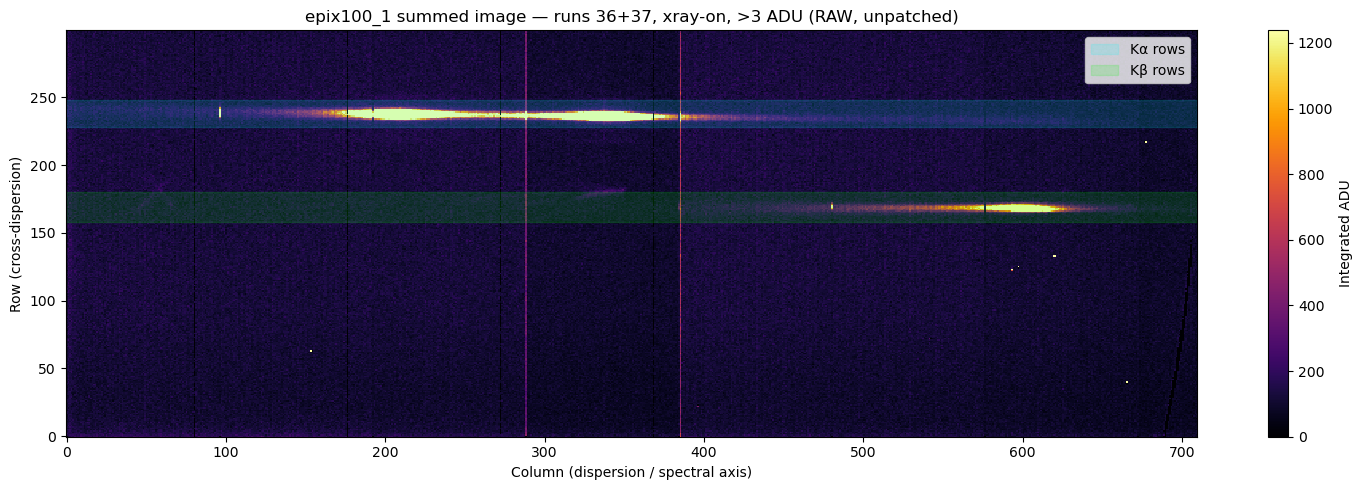

In [3]:
fig, ax = plt.subplots(figsize=(15, 5))
vmax = np.percentile(sum2d, 99.5)
im = ax.imshow(sum2d, aspect='auto', origin='lower', cmap='inferno',
               vmin=0, vmax=vmax, interpolation='nearest')
plt.colorbar(im, ax=ax, label='Integrated ADU')
for (lo, hi), c, lbl in [(KA_ROWS, 'cyan', 'Kα rows'), (KB_ROWS, 'lime', 'Kβ rows')]:
    ax.axhspan(lo, hi, color=c, alpha=0.15, label=lbl)
ax.set_xlabel('Column (dispersion / spectral axis)')
ax.set_ylabel('Row (cross-dispersion)')
ax.set_title('epix100_1 summed image — runs 36+37, xray-on, >3 ADU (RAW, unpatched)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. Automatic spike detection on each 1D spectrum

A spike is a narrow column whose intensity is far above the smooth local
baseline (median filter). We flag columns where the robust z-score exceeds
`NSIGMA` and keep only narrow clusters (≤ `MAX_WIDTH` cols).

Tune `NSIGMA` / `MAX_WIDTH` until the flagged columns (red) match the visible
spikes. Also flag **dead/gap** columns (deep negative dips) the same way.

In [4]:
NSIGMA     = 6.0    # z-score threshold for a spike
MAX_WIDTH  = 3      # max contiguous cols to count as a spike (wider = real signal)
SMOOTH_WIN = 21     # median-filter window for the baseline

def find_spikes(spectrum, nsigma=NSIGMA, max_width=MAX_WIDTH, smooth_win=SMOOTH_WIN):
    """Return (spike_cols, dead_cols, baseline, zscore) for a 1D spectrum."""
    y = np.asarray(spectrum, dtype=float)
    baseline = median_filter(y, size=smooth_win, mode='nearest')
    residual = y - baseline
    # robust local sigma from MAD of the residual
    mad = median_filter(np.abs(residual), size=smooth_win * 2 + 1, mode='nearest')
    sigma = np.maximum(mad * 1.4826, np.abs(baseline) * 0.01 + 1e-9)
    z = residual / sigma
    in_signal = baseline > baseline.max() * 0.02

    def narrow(mask):
        lab, n = label(mask)
        keep = np.zeros_like(mask)
        for i in range(1, n + 1):
            idx = np.where(lab == i)[0]
            if idx.max() - idx.min() + 1 <= max_width:
                keep[idx] = True
        return keep

    spike = narrow(z > nsigma)                    # bright spikes anywhere
    dead  = narrow((z < -nsigma) & in_signal)     # dead/gap dips within signal
    return (np.where(spike)[0], np.where(dead)[0], baseline, z)

ka_spikes, ka_dead, ka_base, ka_z = find_spikes(ka_spec)
kb_spikes, kb_dead, kb_base, kb_z = find_spikes(kb_spec)

print('Fe Kα  spike cols:', list(ka_spikes))
print('Fe Kα  dead  cols:', list(ka_dead))
print('Fe Kβ  spike cols:', list(kb_spikes))
print('Fe Kβ  dead  cols:', list(kb_dead))

Fe Kα  spike cols: [1, 2, 3, 96, 241, 288, 305, 370, 371, 385, 705]
Fe Kα  dead  cols: [80, 176, 192, 239, 272, 306, 368]
Fe Kβ  spike cols: [1, 2, 3, 5, 6, 288, 385, 480, 705, 707]
Fe Kβ  dead  cols: [80, 176, 272, 368, 576]


## 4. Spectra with flagged columns (full range)

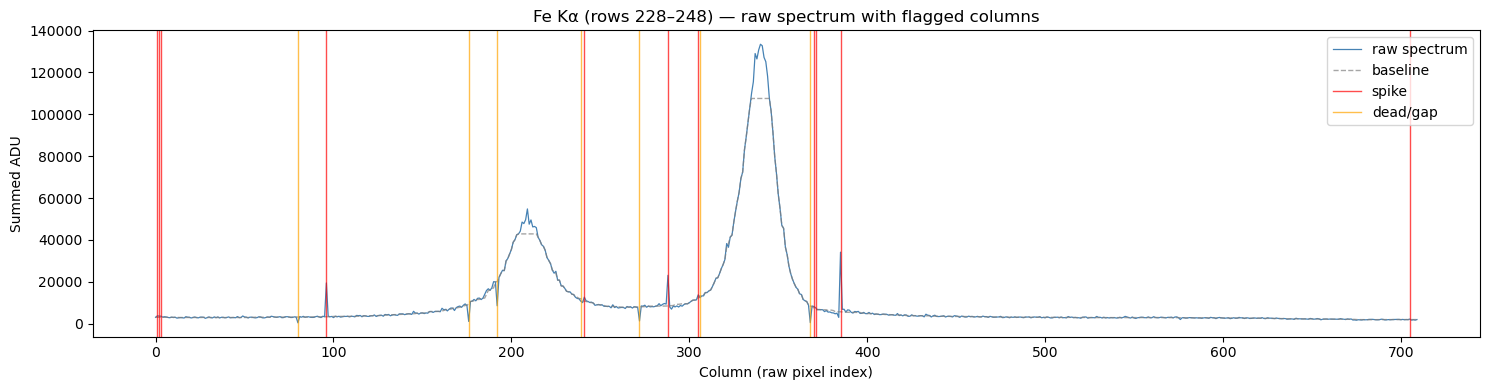

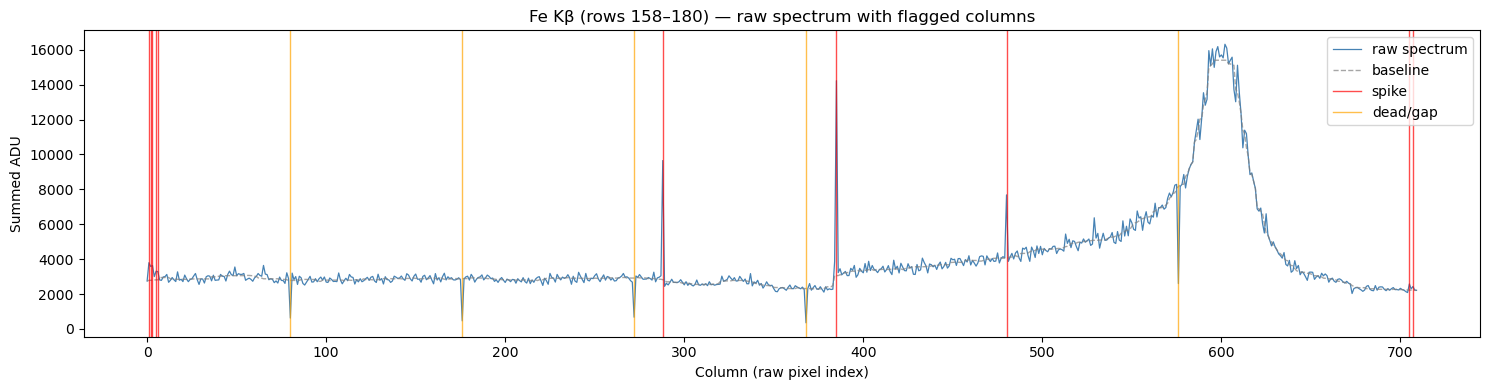

In [5]:
def plot_flagged(spec, base, spikes, dead, label_txt):
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(cols, spec, lw=0.9, color='steelblue', label='raw spectrum')
    ax.plot(cols, base, lw=1.0, color='gray', ls='--', alpha=0.7, label='baseline')
    for i, c in enumerate(spikes):
        ax.axvline(c, color='red', lw=1.0, alpha=0.7,
                   label='spike' if i == 0 else '_')
    for i, c in enumerate(dead):
        ax.axvline(c, color='orange', lw=1.0, alpha=0.7,
                   label='dead/gap' if i == 0 else '_')
    ax.set_xlabel('Column (raw pixel index)')
    ax.set_ylabel('Summed ADU')
    ax.set_title(f'{label_txt} — raw spectrum with flagged columns')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_flagged(ka_spec, ka_base, ka_spikes, ka_dead, 'Fe Kα (rows 228–248)')
plot_flagged(kb_spec, kb_base, kb_spikes, kb_dead, 'Fe Kβ (rows 158–180)')

## 5. Zoom around each flagged column

Inspect ±15 cols around every flagged column to confirm it is a genuine
single/narrow spike (patchable) rather than real spectral structure.

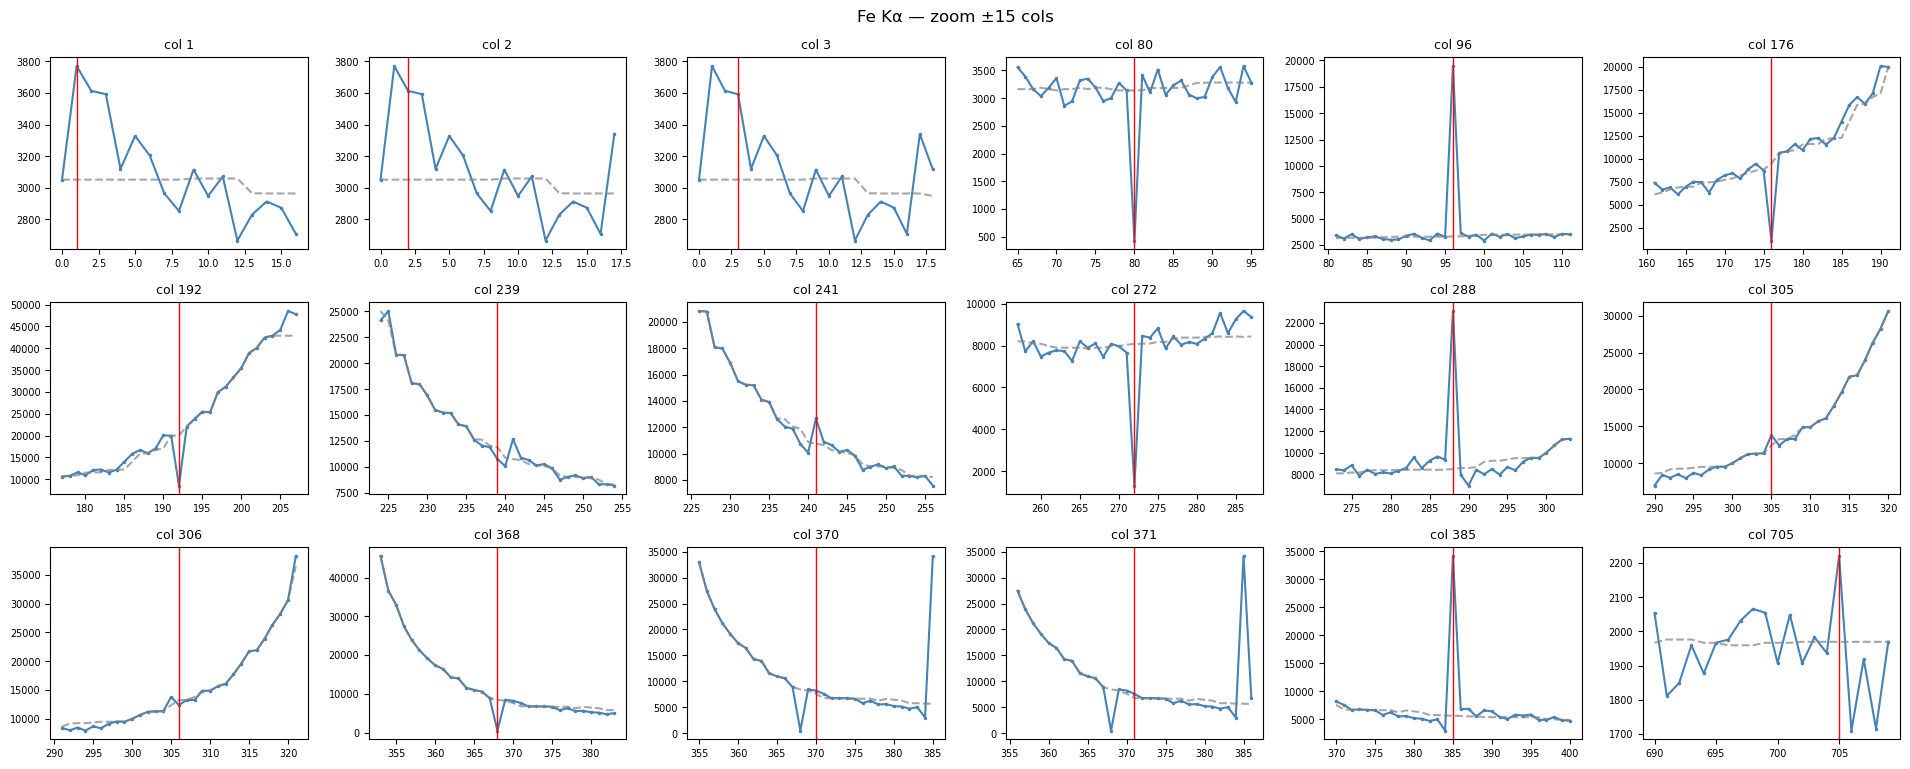

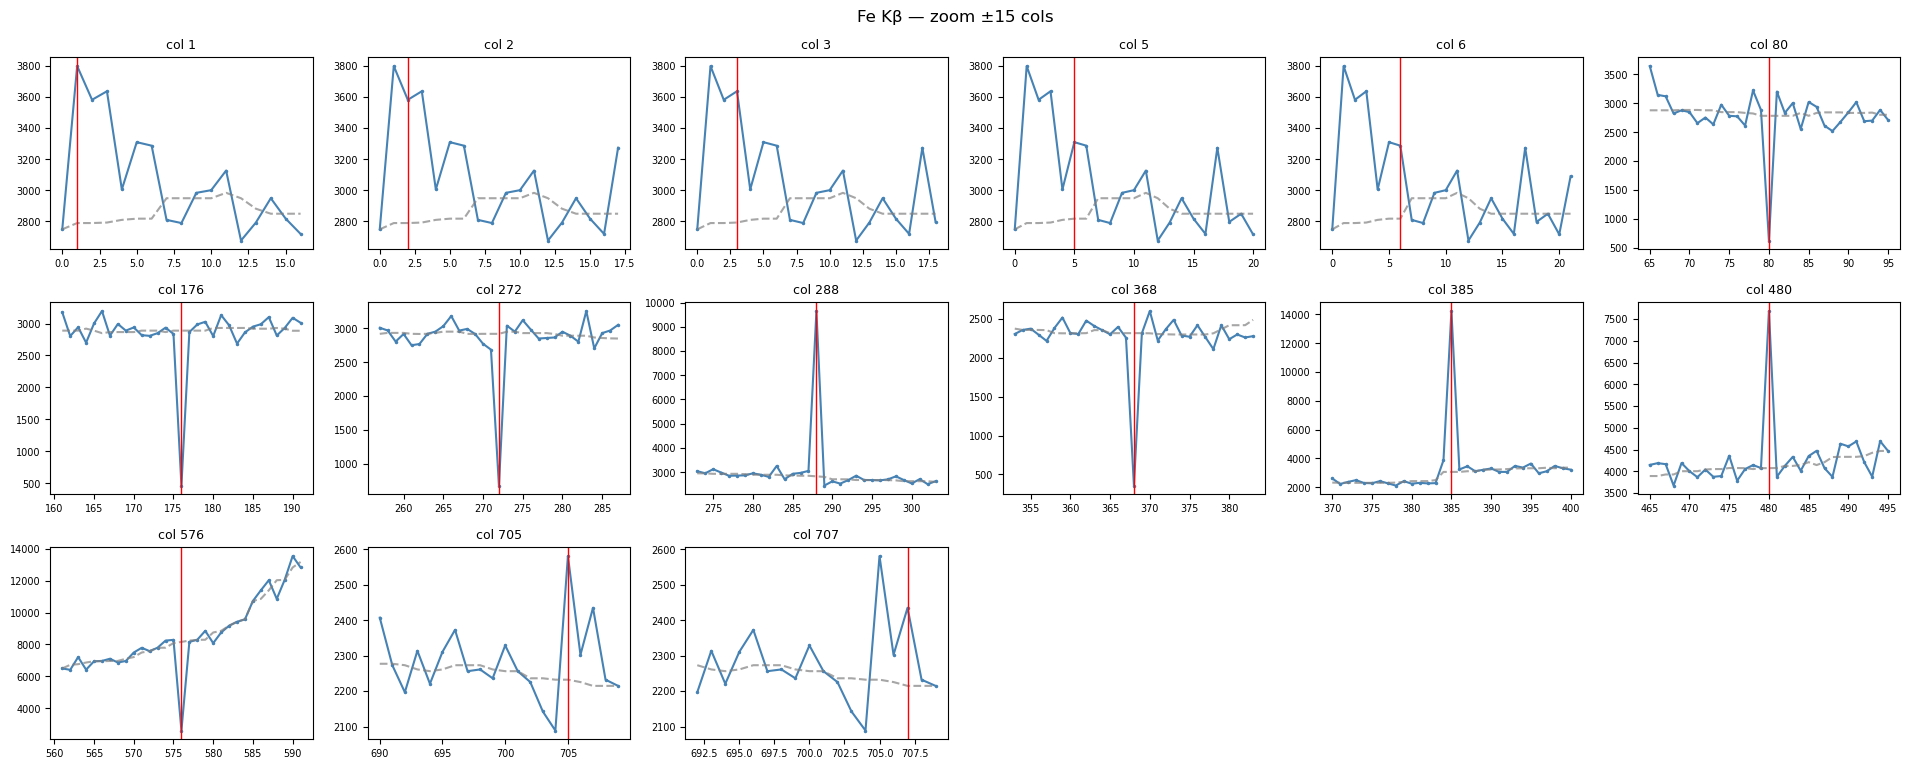

In [6]:
def plot_zoom(spec, base, flagged, label_txt, pad=15):
    flagged = sorted(set(int(c) for c in flagged))
    if not flagged:
        print(f'{label_txt}: no flagged columns to zoom.')
        return
    n = len(flagged)
    ncol = min(n, 6)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.6 * nrow),
                             squeeze=False)
    fig.suptitle(f'{label_txt} — zoom ±{pad} cols', fontsize=12)
    for i, c in enumerate(flagged):
        ax = axes[i // ncol][i % ncol]
        lo, hi = max(0, c - pad), min(len(spec), c + pad + 1)
        x = np.arange(lo, hi)
        ax.plot(x, spec[lo:hi], color='steelblue', marker='.', ms=3)
        ax.plot(x, base[lo:hi], color='gray', ls='--', alpha=0.7)
        ax.axvline(c, color='red', lw=1.0)
        ax.set_title(f'col {c}', fontsize=9)
        ax.tick_params(labelsize=7)
    for j in range(n, nrow * ncol):
        axes[j // ncol][j % ncol].axis('off')
    plt.tight_layout()
    plt.show()

plot_zoom(ka_spec, ka_base, np.concatenate([ka_spikes, ka_dead]), 'Fe Kα')
plot_zoom(kb_spec, kb_base, np.concatenate([kb_spikes, kb_dead]), 'Fe Kβ')

## 6. Final pixel list for the YAML

`patch_pixels` runs on the summed 2D image **before** the row-ROI reduction,
and its `axis: 1` refers to the **column** axis — the same columns we flagged
here. So the union of Kα and Kβ flagged columns is the list to patch.

Add/remove entries in `MANUAL_ADD` / `MANUAL_REMOVE` after inspecting the
zoom panels, then paste the printed list into the YAML.

In [7]:
MANUAL_ADD    = []   # columns you can see are spikes but the detector missed
MANUAL_REMOVE = []   # false positives (real signal) to drop

all_flagged = set(int(c) for c in np.concatenate([
    ka_spikes, ka_dead, kb_spikes, kb_dead
]))
all_flagged |= set(MANUAL_ADD)
all_flagged -= set(MANUAL_REMOVE)
patch_cols = sorted(all_flagged)

print(f'{len(patch_cols)} columns to patch:\n')
print('  # paste into mfx100895324_static_xes.yaml, patch_pixels step:')
print(f'    pixels: {patch_cols}')
print()
print('Recommended patch_pixels block (manual list + keep auto_detect off\n'
      'to use ONLY this explicit list, or leave auto_detect: true to combine):')
print('''
  - step: patch_pixels
    on: epix_reduced
    pixels: %s
    auto_detect: false
    mode: polynomial
    axis: 1
''' % patch_cols)

23 columns to patch:

  # paste into mfx100895324_static_xes.yaml, patch_pixels step:
    pixels: [1, 2, 3, 5, 6, 80, 96, 176, 192, 239, 241, 272, 288, 305, 306, 368, 370, 371, 385, 480, 576, 705, 707]

Recommended patch_pixels block (manual list + keep auto_detect off
to use ONLY this explicit list, or leave auto_detect: true to combine):

  - step: patch_pixels
    on: epix_reduced
    pixels: [1, 2, 3, 5, 6, 80, 96, 176, 192, 239, 241, 272, 288, 305, 306, 368, 370, 371, 385, 480, 576, 705, 707]
    auto_detect: false
    mode: polynomial
    axis: 1



## 7. (Optional) preview the patched result

Apply the same polynomial patch the pipeline uses to the summed 2D image and
compare before/after spectra, so you can confirm the list works before
editing the YAML.

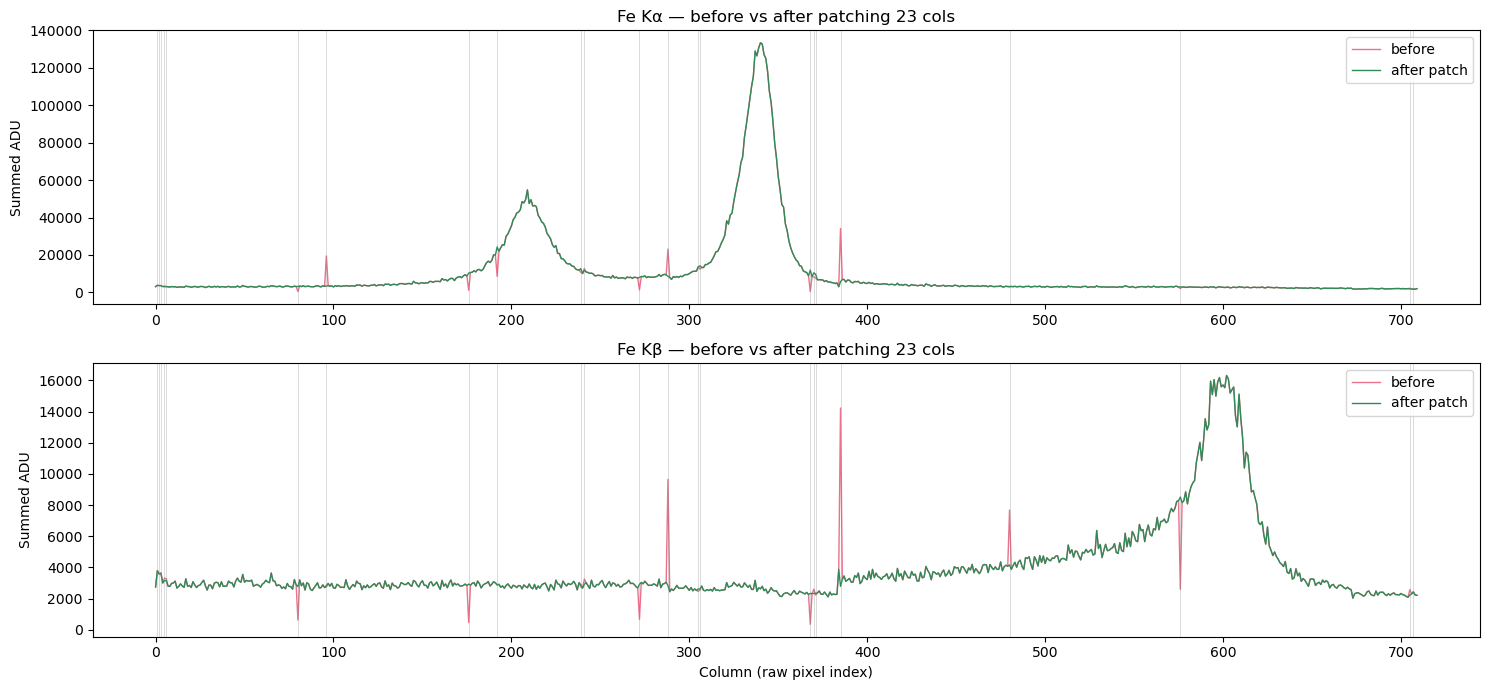

In [8]:
def patch_columns_2d(img, cols_to_patch, patch_range=4, poly_range=6, deg=1):
    """Polynomial column patch on a 2D image (axis 1 = columns), matching the
    XSpect patch_pixels algorithm closely enough for a visual preview."""
    out = img.copy().astype(float)
    ncols = out.shape[1]
    bad = set(int(c) for c in cols_to_patch)
    for c in sorted(bad):
        lo = max(c - patch_range - poly_range, 0)
        hi = min(c + patch_range + poly_range + 1, ncols)
        xr = np.arange(lo, hi)
        w = np.ones(len(xr))
        for b in bad:
            k = b - lo
            a0, a1 = max(k - patch_range, 0), min(k + patch_range + 1, len(w))
            if a0 < len(w) and a1 > 0:
                w[a0:a1] = 0.0
        if (w > 0.5).sum() < 4:
            continue
        region = out[:, lo:hi]                      # (rows, region)
        X = np.vander(xr.astype(float), deg + 1)
        W = w ** 2
        XtW = X.T * W[None, :]
        proj = np.vander(np.array([float(c)]), deg + 1)[0] @ np.linalg.solve(XtW @ X, XtW)
        out[:, c] = region @ proj
    return out

sum2d_patched = patch_columns_2d(sum2d, patch_cols)
ka_patched = sum2d_patched[KA_ROWS[0]:KA_ROWS[1], :].sum(axis=0)
kb_patched = sum2d_patched[KB_ROWS[0]:KB_ROWS[1], :].sum(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(15, 7))
for ax, raw, patched, lbl in [
    (axes[0], ka_spec, ka_patched, 'Fe Kα'),
    (axes[1], kb_spec, kb_patched, 'Fe Kβ'),
]:
    ax.plot(cols, raw, lw=1.0, color='crimson', alpha=0.6, label='before')
    ax.plot(cols, patched, lw=1.0, color='seagreen', label='after patch')
    for c in patch_cols:
        ax.axvline(c, color='gray', lw=0.5, alpha=0.4)
    ax.set_ylabel('Summed ADU')
    ax.set_title(f'{lbl} — before vs after patching {len(patch_cols)} cols')
    ax.legend(loc='upper right')
axes[-1].set_xlabel('Column (raw pixel index)')
plt.tight_layout()
plt.show()